In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
import heapq
import math

In [7]:
def calculate_cost(graph, u, v):
    length = graph[u][v]['length']
    radius = graph[u][v]['diameter'] / 2
    viscosity = 0.004  # Pa·s
    flux = graph[u][v]['flux']
    resistance = (8 * viscosity * length) / (math.pi * radius**4)
    return resistance * flux

In [9]:
def calculate_cost_simple(graph, u, v):
    length = graph[u][v]['length']
    diameter = graph[u][v]['diameter']
    flux = graph[u][v]['flux']
    return (length / diameter) * flux

## ACO Functions

In [12]:
def chose_next(graph, current, pheromone, alfa, beta):
    probabilities = []
    neighbours = list(graph.successors(current))
    if not neighbours:
        return None
    for j in neighbours:
        phe = pheromone[current][j] ** alfa
        dist = (1/graph[current][j]['cost']) ** beta
        probabilities.append(phe * dist)
    total = sum(probabilities)
    probabilities = [p / total for p in probabilities]
    return random.choices(neighbours, weights=probabilities)[0]
def build_path(graph, start, end, pheromone, alfa, beta, max_steps=20):
    current = start
    path = [start]
    while current != end:
        if len(path) > max_steps:
            return None
        next_node = chose_next(graph, current, pheromone, alfa, beta)
        if next_node is None:
            return None
        path.append(next_node)
        current = next_node
    return path
def calculate_length(graph, path):
    total = 0
    for i in range(len(path) - 1):
        total += graph[path[i]][path[i+1]]['cost']
    return total
def update_pheromones(graph, pheromone, paths, evaporation):
    pheromone*= (1 - evaporation)  

    for path in paths:
        length= calculate_length(graph, path)
        for i in range(len(path) - 1):
            pheromone[path[i]][path[i+1]] += 1 / length

## A* Algorithm

In [15]:
def heuristic(nodes, u, v):
    x1, y1 = nodes[u]
    x2, y2 = nodes[v]
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)
    
def a_star(graph, nodes, start, end):
    pq = [(0+heuristic(nodes, start, end), start)]     
    distances = {start: 0}  
    parents = {start: None}
    visited = set()

    while pq:
        current_priority, current = heapq.heappop(pq)

        if current in visited:
            continue
        visited.add(current)

        if current == end:
            path = []
            node = end
            while node is not None:
                path.append(node)
                node = parents[node]
            path.reverse()
            return path

        for neighbour in graph.successors(current):
            weight = graph[current][neighbour]['cost']
            new_dist = distances[current] + weight

            if neighbour not in distances or new_dist < distances[neighbour]:
                distances[neighbour] = new_dist
                parents[neighbour] = current
                heapq.heappush(pq, (new_dist+heuristic(nodes, neighbour, end), neighbour))

    return None

## 1. Small Vascular Network (8 nodes)
Baseline test to verify algorithm correctness. Both algorithms expected to find the same optimal path.

In [18]:
G = nx.DiGraph()  
nodes = {
    0: (0, 0),
    1: (2, 1),
    2: (2, -1),
    3: (4, 2),
    4: (4, 0),
    5: (4, -2),
    6: (6, 1),
    7: (6, -1)
}
for node, (x, y) in nodes.items():
    G.add_node(node, pos=(x, y))
edges = [
    (0, 1, {'length': 2.5, 'diameter': 0.4, 'flux': 1}),
    (0, 2, {'length': 2.5, 'diameter': 0.3, 'flux': 1}),
    (1, 3, {'length': 2.5, 'diameter': 0.3, 'flux': 1}),
    (1, 4, {'length': 2.0, 'diameter': 0.2, 'flux': 1}),
    (2, 4, {'length': 2.0, 'diameter': 0.2, 'flux': 1}),
    (2, 5, {'length': 2.5, 'diameter': 0.3, 'flux': 1}),
    (3, 6, {'length': 2.5, 'diameter': 0.2, 'flux': 1}),
    (4, 6, {'length': 2.0, 'diameter': 0.3, 'flux': 1}),
    (4, 7, {'length': 2.0, 'diameter': 0.2, 'flux': 1}),
    (5, 7, {'length': 2.5, 'diameter': 0.2, 'flux': 1}),
]
for u, v, props in edges:
    G.add_edge(u, v, **props)

for u, v in G.edges():
    G[u][v]['cost'] = calculate_cost(G, u, v)

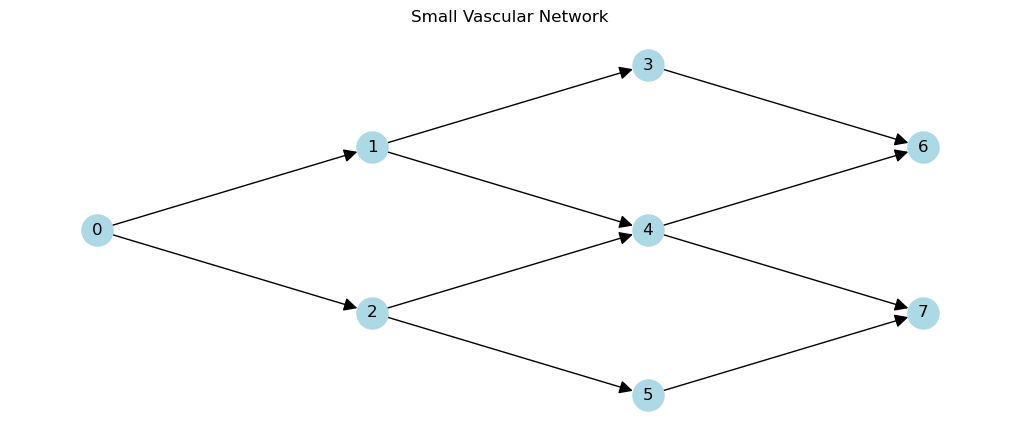

In [20]:
pos = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(10, 4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, arrows=True, arrowsize=20)
plt.title("Small Vascular Network")
plt.show()

## ACO Loop

In [23]:
best_path = None
best_length = float('inf')
history = []


n_nodes = G.number_of_nodes()
pheromone = np.ones((n_nodes, n_nodes))
n_bots = 5
n_interactions = 100
alfa = 1
beta = 2
evaporation = 0.5

for iteraction in range(n_interactions):
    all_paths = [build_path(G, 0, 6, pheromone, alfa, beta) for _ in range(n_bots)]
    paths = [c for c in all_paths if c is not None]
    if not paths:
        continue
    update_pheromones(G, pheromone, paths, evaporation)
    
    for path in paths:
        length = calculate_length(G, path)
        if length < best_length:
            best_length = length
            best_path = path
    
    history.append(best_length)

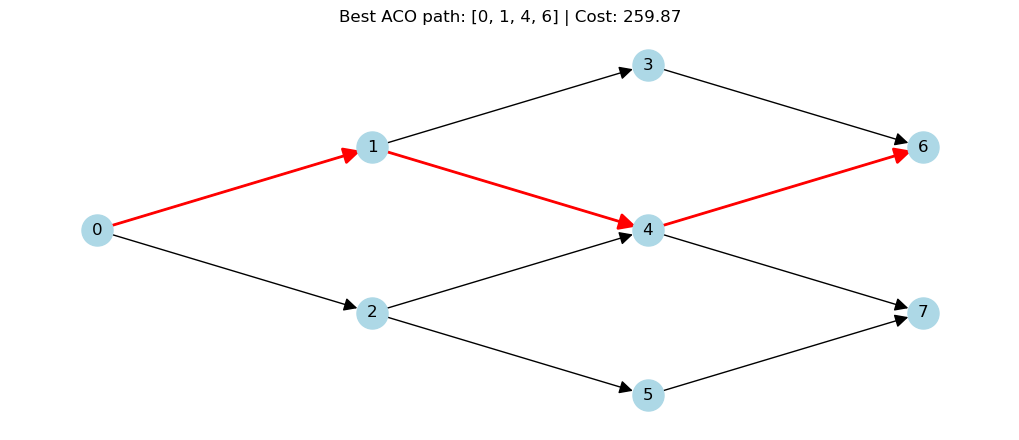

In [25]:
pos = nx.get_node_attributes(G, 'pos')
path_edges = [(best_path[i], best_path[i+1]) for i in range(len(best_path)-1)]

plt.figure(figsize=(10, 4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, arrows=True, arrowsize=20)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2, arrows=True, arrowsize=25)
plt.title(f"Best ACO path: {best_path} | Cost: {best_length:.2f}")
plt.show()

In [26]:
path_astar = a_star(G, nodes, 0, 6)
cost_astar = calculate_length(G, path_astar)

print("Comparison A* vs ACO:")
print(f"A*  - Path: {path_astar} | Cost: {cost_astar:.2f}")
print(f"ACO - Path: {best_path} | Cost: {best_length:.2f}")

Comparison A* vs ACO:
A*  - Path: [0, 1, 4, 6] | Cost: 259.87
ACO - Path: [0, 1, 4, 6] | Cost: 259.87


## 2. Medium Vascular Network (50 nodes)
Both algorithms compared on path cost, execution time and path length.

In [30]:
random.seed(42)
n_nodes_50= 50
G_50 = nx.DiGraph()

nodes_50 = {i: (random.uniform(0,20), random.uniform(0,20)) for i in range(n_nodes_50)} 
for node, (x,y) in nodes_50.items(): 
    G_50.add_node(node, pos=(x,y))

for i in range(n_nodes_50):
    n_neighbours = random.randint(2, 5)
    candidates = [j for j in range(i+1, n_nodes_50)]
    if not candidates:
        continue
    neighbours = random.sample(candidates, min(n_neighbours, len(candidates))) 
    for j in neighbours: 
        length = random.uniform(1, 5)
        diameter = random.uniform(0.1, 0.5)
        flux = random.choice([1, 2])
        G_50.add_edge(i, j, length=length, diameter=diameter, flux=flux)

for u, v in G_50.edges():
    G_50[u][v]['cost'] = calculate_cost(G_50, u, v)

In [32]:
best_path = None
best_length = float('inf')
history = []


n_nodes = G_50.number_of_nodes()
pheromone = np.ones((n_nodes, n_nodes))
n_bots = 5
n_interactions = 100
alfa = 1
beta = 2
evaporation = 0.5

import time
start = time.perf_counter()
path_astar = a_star(G_50, nodes_50, 0, 49)
time_astar = time.perf_counter() - start

start = time.perf_counter()

for iteraction in range(n_interactions):
    all_paths = [build_path(G_50, 0, 49, pheromone, alfa, beta) for _ in range(n_bots)]
    paths = [c for c in all_paths if c is not None]
    if not paths:
        continue
    update_pheromones(G_50, pheromone, paths, evaporation)
    
    for path in paths:
        length = calculate_length(G_50, path)
        if length < best_length:
            best_length = length
            best_path = path
    time_aco = time.perf_counter() - start
    
    history.append(best_length)

In [34]:
path_astar = a_star(G_50, nodes_50, 0, 49)
cost_astar = calculate_length(G_50, path_astar)

print("Comparison A* vs ACO:")
print(f"A* - Time: {time_astar:.4f}s")
print(f"ACO - Time: {time_aco:.4f}s")
print(f"A*  - Path: {path_astar} | Cost: {cost_astar:.2f}")
print(f"ACO - Path: {best_path} | Cost: {best_length:.2f}")

Comparison A* vs ACO:
A* - Time: 0.0004s
ACO - Time: 0.0557s
A*  - Path: [0, 44, 49] | Cost: 32.46
ACO - Path: [0, 44, 49] | Cost: 32.46


## 3. Large Vascular Network (500 nodes): Poiseuille Model
Cost model: Poiseuille's law — R = (8ηL) / (πr⁴)

In [37]:
random.seed(42)
n_nodes_500= 500
G_500 = nx.DiGraph() 

nodes_500 = {i: (random.uniform(0,20), random.uniform(0,20)) for i in range(n_nodes_500)} 
for node, (x,y) in nodes_500.items(): 
    G_500.add_node(node, pos=(x,y))

for i in range(n_nodes_500):
    n_neighbours = random.randint(2, 5) 
    candidates = [j for j in range(i+1, n_nodes_500)]
    if not candidates:
        continue
    neighbours = random.sample(candidates, min(n_neighbours, len(candidates))) 
    for j in neighbours: 
        length = random.uniform(1, 5)
        diameter = random.uniform(0.1, 0.5)
        flux = random.choice([1, 2])
        G_500.add_edge(i, j, length=length, diameter=diameter, flux=flux)

for u, v in G_500.edges():
    G_500[u][v]['cost'] = calculate_cost(G_500, u, v)

In [39]:
best_path = None
best_length = float('inf')
history_poiseuille = []


n_nodes = G_500.number_of_nodes()
pheromone = np.ones((n_nodes, n_nodes))
n_bots = 5
n_interactions = 100
alfa = 1
beta = 2
evaporation = 0.5

import time
start = time.perf_counter()
path_astar = a_star(G_500, nodes_500, 0, 499)
time_astar = time.perf_counter() - start

start = time.perf_counter()

for iteraction in range(n_interactions):
    all_paths = [build_path(G_500, 0, 499, pheromone, alfa, beta) for _ in range(n_bots)]
    paths = [c for c in all_paths if c is not None]
    if not paths:
        continue
    update_pheromones(G_500, pheromone, paths, evaporation)
    
    for path in paths:
        length = calculate_length(G_500, path)
        if length < best_length:
            best_length = length
            best_path = path
    time_aco = time.perf_counter() - start
    
    history_poiseuille.append(best_length)

In [41]:
path_astar = a_star(G_500, nodes_500, 0, 499)
cost_astar = calculate_length(G_500, path_astar)

print("Comparison A* vs ACO:")
print(f"A* - Time: {time_astar:.4f}s")
print(f"ACO - Time: {time_aco:.4f}s")
print(f"A*  - Path: {path_astar} | Cost: {cost_astar:.2f}")
print(f"ACO - Path: {best_path} | Cost: {best_length:.2f}")

Comparison A* vs ACO:
A* - Time: 0.0009s
ACO - Time: 0.0918s
A*  - Path: [0, 352, 467, 497, 499] | Cost: 82.83
ACO - Path: [0, 352, 448, 454, 478, 499] | Cost: 127.94


## 4. Large Vascular Network (500 nodes): Simple Cost Model
Cost model: length / diameter × flux

In [44]:
for u, v in G_500.edges():
    G_500[u][v]['cost'] = calculate_cost_simple(G_500, u, v)
    
pheromone_500 = np.ones((n_nodes_500, n_nodes_500))
path_astar = a_star(G_500, nodes_500, 0, 499)
cost_astar = calculate_length(G_500, path_astar)

best_path = None
best_length = float('inf')
history_simple = []


n_nodes = G_500.number_of_nodes()
pheromone = np.ones((n_nodes, n_nodes))
n_bots = 5
n_interactions = 100
alfa = 1
beta = 2
evaporation = 0.5

import time
start = time.perf_counter()
path_astar = a_star(G_500, nodes_500, 0, 499)
time_astar = time.perf_counter() - start

start = time.perf_counter()

for iteraction in range(n_interactions):
    all_paths = [build_path(G_500, 0, 499, pheromone, alfa, beta) for _ in range(n_bots)]
    paths = [c for c in all_paths if c is not None]
    if not paths:
        continue
    update_pheromones(G_500, pheromone, paths, evaporation)
    
    for path in paths:
        length = calculate_length(G_500, path)
        if length < best_length:
            best_length = length
            best_path = path
    time_aco = time.perf_counter() - start
    
    history_simple.append(best_length)
    
print("Comparison A* vs ACO:")
print(f"A* - Time: {time_astar:.4f}s")
print(f"ACO - Time: {time_aco:.4f}s")
print(f"A*  - Path: {path_astar} | Cost: {cost_astar:.2f}")
print(f"ACO - Path: {best_path} | Cost: {best_length:.2f}")

Comparison A* vs ACO:
A* - Time: 0.0005s
ACO - Time: 0.1119s
A*  - Path: [0, 189, 473, 499] | Cost: 32.94
ACO - Path: [0, 189, 214, 455, 496, 499] | Cost: 31.11


## 5. Results Summary

| Graph | Cost Model | Algorithm | Path Cost | Time (s) | Nodes in Path |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 8 nodes | Poiseuille | A* | 259.87 | - | 3 |
| 8 nodes | Poiseuille | ACO | 259.87 | - | 3 |
| 50 nodes | Poiseuille | A* | 32.46 | 0.0003 | 3 |
| 50 nodes | Poiseuille | ACO | 32.46 | 0.0804 | 3 |
| 500 nodes | Simple | A* | 32.94 | 0.0007 | 4 |
| 500 nodes | Simple | ACO | 31.11 | 0.1366 | 6 |
| 500 nodes | Poiseuille | A* | 82.83 | 0.0008 | 5 |
| 500 nodes | Poiseuille | ACO | 127.94 | 0.0980 | 6 |

## 6. ACO Convergence Analysis

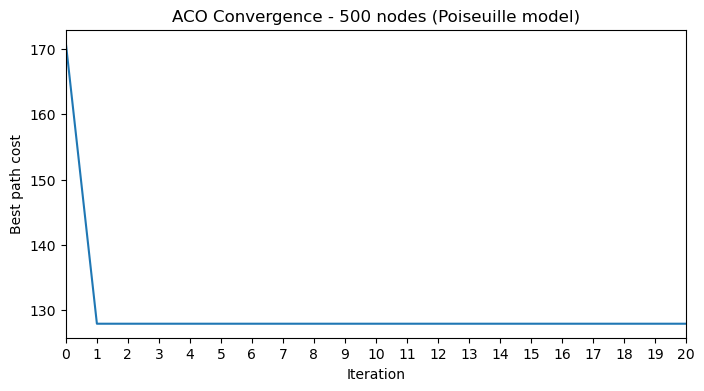

In [54]:
plt.figure(figsize=(8, 4))
plt.plot(history_poiseuille)
plt.xlabel("Iteration")
plt.xlim([0, 20])
plt.xticks(range(0, 21, 1))
plt.ylabel("Best path cost")
plt.title("ACO Convergence - 500 nodes (Poiseuille model)")
plt.show()

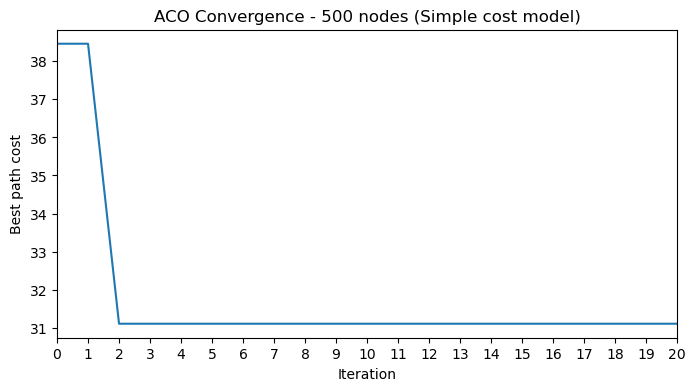

In [56]:
plt.figure(figsize=(8, 4))
plt.plot(history_simple)
plt.xlabel("Iteration")
plt.xlim([0, 20])
plt.xticks(range(0, 21, 1))
plt.ylabel("Best path cost")
plt.title("ACO Convergence - 500 nodes (Simple cost model)")
plt.show()